In [68]:
import pandas as pd
import numpy as np

### Day 1. 

### Data Understanding & Cleaning.

In [69]:
# Loading data from all csv files.

train = pd.read_csv("train.csv.zip", compression="zip")
features = pd.read_csv("features.csv.zip", compression="zip")
store = pd.read_csv("stores.csv")

### 1. train.csv file

In [70]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [71]:
train.tail()


,Store,Dept,Date,Weekly_Sales,IsHoliday
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False
421569,45,98,2012-10-26,1076.80,False


In [72]:
train.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [73]:
train.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [74]:
# Changing date format from string to date format

train["Date"] = pd.to_datetime(train["Date"], format="%Y-%m-%d")

In [75]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB


In [76]:
train.shape

(421570, 5)

### 2. stores.csv file

In [77]:
store.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [78]:
store.isnull().sum()


Store    0
Type     0
Size     0
dtype: int64

In [79]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [80]:
store.shape

(45, 3)

### 3. features.csv file

In [81]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [82]:
features.isnull().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [83]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [84]:
features.shape

(8190, 12)

In [85]:
features["CPI"] = features["CPI"].ffill()
features["Unemployment"] = features["Unemployment"].ffill()

In [86]:
features.isnull().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI                0
Unemployment       0
IsHoliday          0
dtype: int64

### Data Combining Or Merging.

In [87]:
# Merging 'train.csv' to 'features.csv' cause more common column

features["Date"] = pd.to_datetime(features["Date"], format="%Y-%m-%d")

In [88]:
df_temp = train.merge(features, on=["Store","Date","IsHoliday"], how="left")

In [89]:
df_temp.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [90]:
df_temp.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
dtype: int64

In [91]:
df_temp = df_temp.drop(["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"], axis = 1)

In [92]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   CPI           421570 non-null  float64       
 8   Unemployment  421570 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(5), int64(2)
memory usage: 26.1 MB


In [93]:
# Merging "df_temp" to "stores.csv"

df = df_temp.merge(store, on="Store", how="left")

In [94]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   CPI           421570 non-null  float64       
 8   Unemployment  421570 non-null  float64       
 9   Type          421570 non-null  object        
 10  Size          421570 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(5), int64(3), object(1)
memory usage: 32.6+ MB


In [96]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Type', 'Size'],
      dtype='object')

In [97]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [98]:
df.shape

(421570, 11)

In [99]:
df.duplicated().sum()

0

In [100]:
#Using only those Columns that mention in the pdf.

df = df[['Store','Dept','Date','Weekly_Sales','IsHoliday','Temperature',
         'Fuel_Price','CPI','Unemployment']]

In [101]:
# DataSet is clean and ready for further use.

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106


In [102]:
df.shape

(421570, 9)

### Day 2.

###  Exploratory Data Analysis (EDA).

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

### Univariate Analysis (Single Variable).

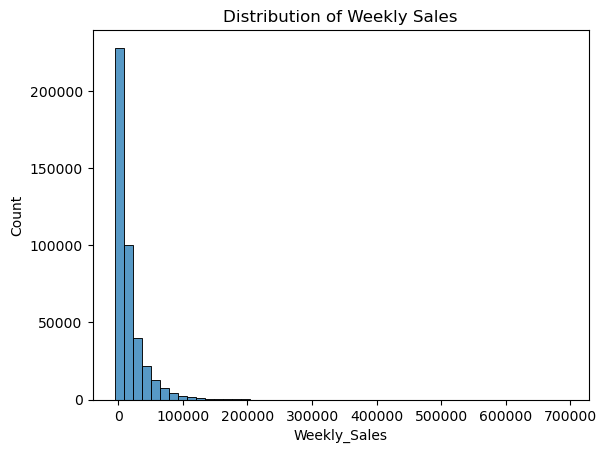

In [104]:
sns.histplot(df["Weekly_Sales"],bins=50)
plt.title("Distribution of Weekly Sales")
plt.show()

In [ ]:
Observation:-
    Most weekly sales values are concentrated in the lower range with 
some extreme high values.

### Bivariate Analysis

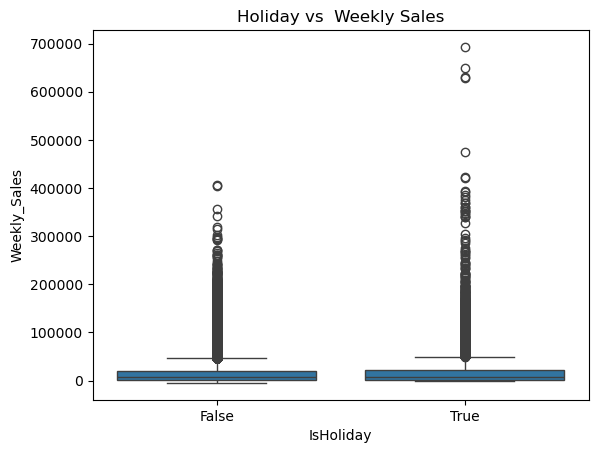

In [105]:
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=df)
plt.title("Holiday vs  Weekly Sales")
plt.show()

In [ ]:
Observation:-
    Weekly sales tend to be higher and more variable during holiday weeks compared to 
non-holiday weeks, indicating that holidays significantly influence customer purchasing 
behavior.

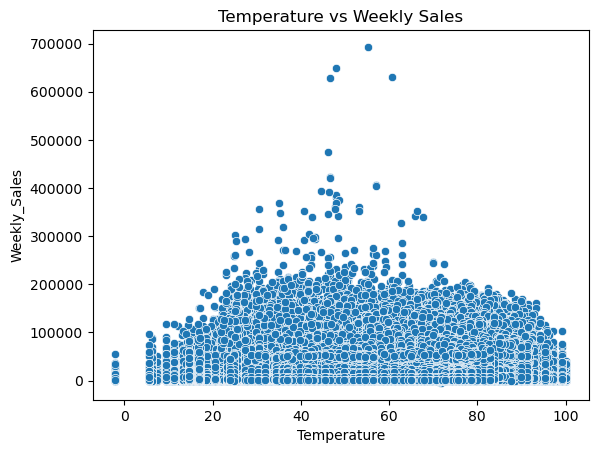

In [106]:
# Temperature vs Weekly Sales.

sns.scatterplot(x="Temperature",y="Weekly_Sales",data=df)
plt.title("Temperature vs Weekly Sales")
plt.show()

In [ ]:
Observation:-
    Weekly sales do not show a strong relationship with temperature, 
suggesting weather has limited direct impact on store sales.

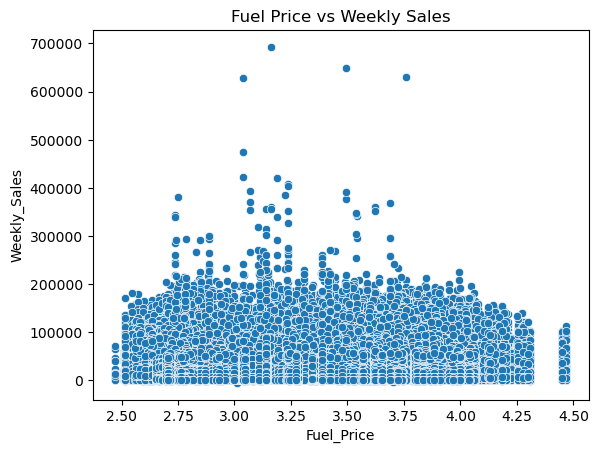

In [107]:
# Fuel_Price vs Weekly Sales.

sns.scatterplot(x="Fuel_Price", y ="Weekly_Sales", data=df)
plt.title("Fuel Price vs Weekly Sales")
plt.show()

In [ ]:
Observation:-
    Fuel price shows weak correlation with weekly sales, 
meaning fluctuations in fuel price may not significantly affect 
customer purchasing patterns.

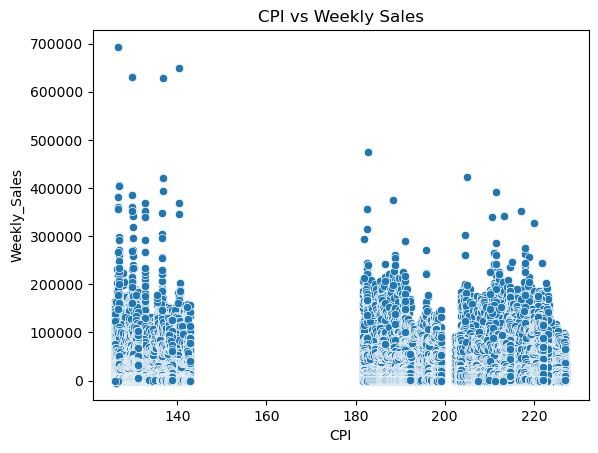

In [108]:
# CPI vs Weekly Sales-

sns.scatterplot(x="CPI", y="Weekly_Sales", data=df)
plt.title("CPI vs Weekly Sales")
plt.show()

In [ ]:
Observation:-
    CPI appears to have minimal influence on weekly sales, indicating 
that inflation changes may not immediately impact weekly purchasing behavior.

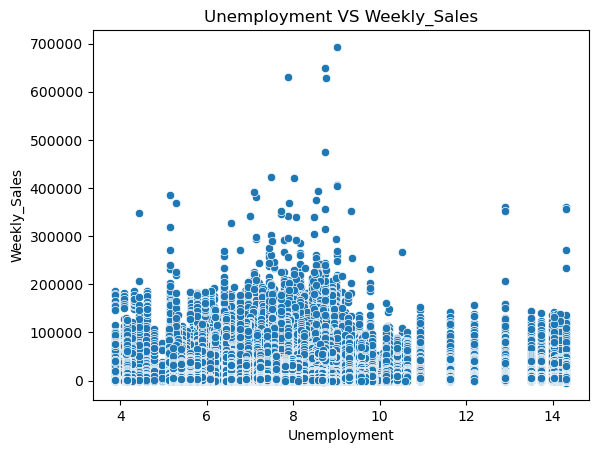

In [109]:
# Unemployment VS Weekly_Sales.

sns.scatterplot(x="Unemployment",y="Weekly_Sales", data=df)
plt.title("Unemployment VS Weekly_Sales")
plt.show()

In [ ]:
Observation:-
    Unemployment rate shows weak association with weekly sales, 
suggesting that short-term employment changes do not strongly 
impact weekly store revenue.

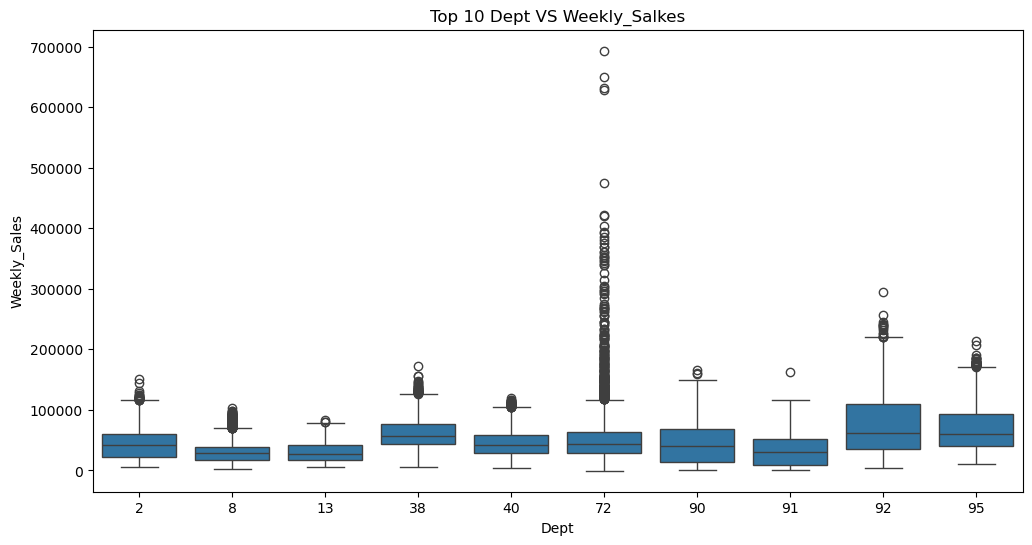

In [110]:
# Dept VS Weekly_Sales.

top_dept = df.groupby("Dept")["Weekly_Sales"].sum().nlargest(10).index
filtered_df = df[df["Dept"].isin(top_dept)]

plt.figure(figsize=(12,6))
sns.boxplot(x="Dept", y="Weekly_Sales", data=filtered_df)

plt.title("Top 10 Dept VS Weekly_Salkes")
plt.show()

In [ ]:
Observation:-
    Sales vary significantly across departments, indicating that certain product 
categories generate much higher revenue than others.It can be observed that sales 
are not equally distributed across all departments. Some departments like 72, 92 
and 95 show higher sales compared to others. Department 72 especially has a very 
large spread and many extreme values, which indicates that its sales vary a lot and 
sometimes go very high. On the other hand, departments like 8, 13 and 91 have 
comparatively lower sales and less variation.

### Top Performing Stores

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64


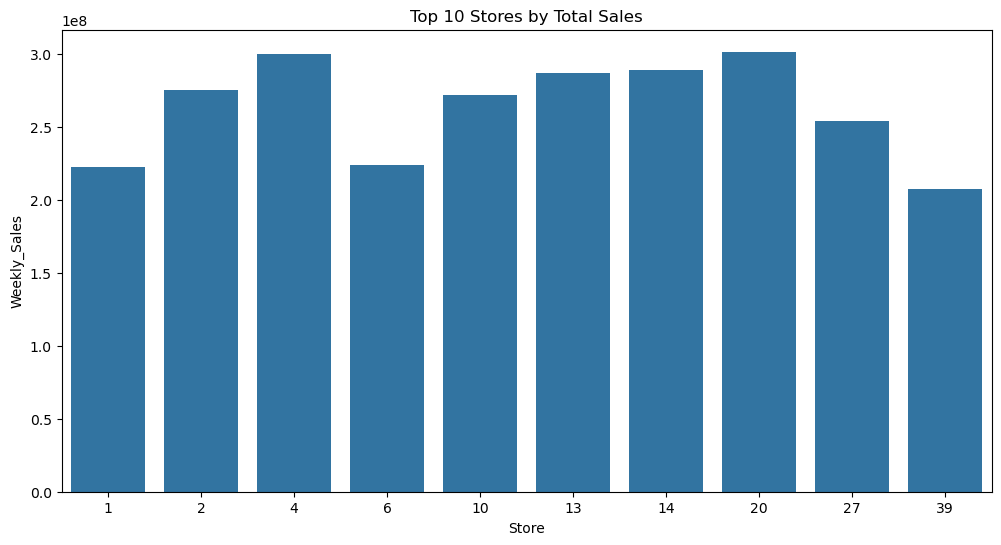

In [111]:
# Total sales per Stores
Store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)

print(Store_sales.head(10))

plt.figure(figsize=(12,6))
sns.barplot(x=Store_sales.head(10).index, y=Store_sales.head(10).values)
plt.title("Top 10 Stores by Total Sales")
plt.ylabel("Weekly_Sales")
plt.show()

In [ ]:
Observation:-
    Store 4 and 20 generates the highest weekly sales, 
making it a top-performing store.

### Top Performing Department


Dept
92    4.839433e+08
95    4.493202e+08
38    3.931181e+08
72    3.057252e+08
90    2.910685e+08
40    2.889360e+08
2     2.806112e+08
91    2.167817e+08
13    1.973216e+08
8     1.942808e+08
Name: Weekly_Sales, dtype: float64


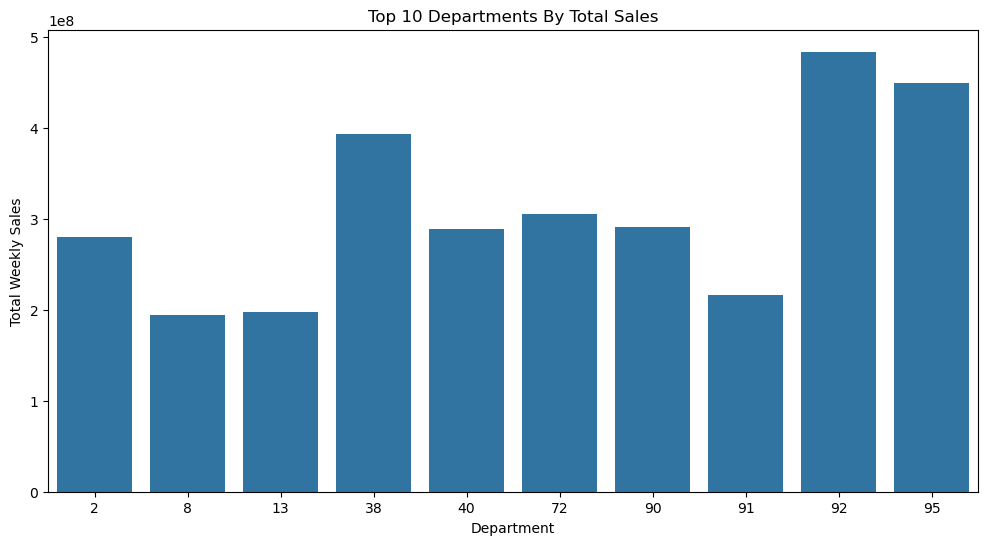

In [112]:
# Total Sales per Dept 

Dept_sales = df.groupby("Dept")["Weekly_Sales"].sum().sort_values(ascending=False)

print(Dept_sales.head(10))

plt.figure(figsize=(12,6))
sns.barplot(x=Dept_sales.head(10).index, y=Dept_sales.head(10).values)
plt.title("Top 10 Departments By Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Weekly Sales")
plt.show()

In [ ]:
Observation:-
    Department 92, 95 and 38 generates the highest weekly sales, 
making it a top 3 performing store.

In [113]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106


### Visualize trends (monthly, seasonal) using line plots and bar charts.

In [114]:
# Extract Month and Year directly.

df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [115]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,2,2010
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,2,2010
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,2,2010
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,2,2010
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,3,2010


In [116]:
df.shape

(421570, 11)

### Monthly Total Sales

Month
1     3.325984e+08
2     5.687279e+08
3     5.927859e+08
4     6.468598e+08
5     5.571256e+08
6     6.226299e+08
7     6.500010e+08
8     6.130902e+08
9     5.787612e+08
10    5.847848e+08
11    4.130157e+08
12    5.768386e+08
Name: Weekly_Sales, dtype: float64


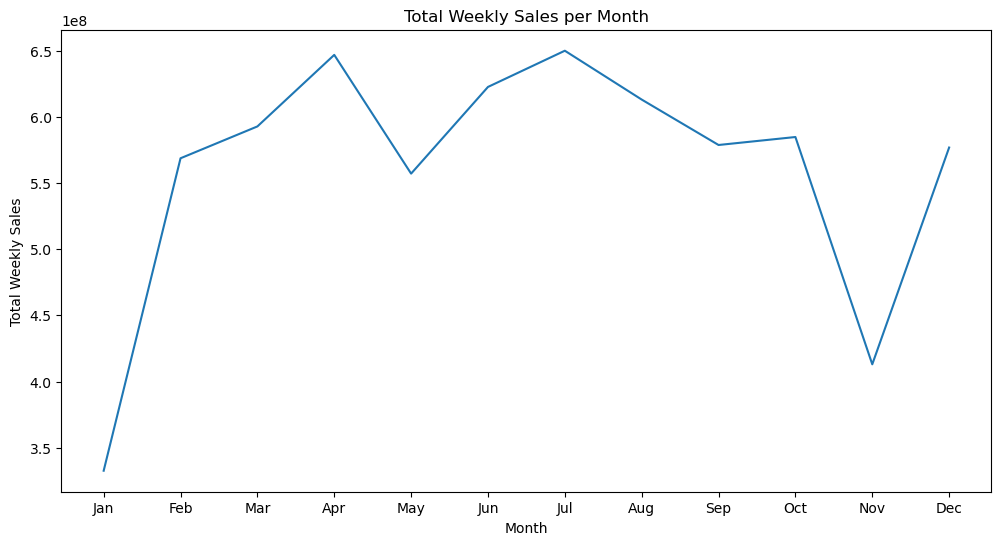

In [117]:
monthly_sales = df.groupby("Month")["Weekly_Sales"].sum()

print(monthly_sales.head(12))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 
               'Sep', 'Oct', 'Nov' , 'Dec']

plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Total Weekly Sales per Month")
plt.xlabel("Month")
plt.ylabel("Total Weekly Sales")
plt.xticks(ticks=range(1,13), labels=month_names)
plt.show()

In [ ]:
Observation:
    Weekly sales show noticeable patterns throughout the year. Sales increase in March,
likely due to spring season shopping. From June to August, sales rise again, driven by 
summer vacations and Independence Day promotions. There is a slight dip in October and 
November before the holiday season. Finally, sales peak in December because of Black 
Friday, Thanksgiving, and Christmas shopping.

### Monthly Average Sales

Month
1     14126.075111
2     16008.779217
3     15416.657597
4     15650.338357
5     15776.337202
6     16326.137002
7     15861.419650
8     16062.516933
9     15095.886154
10    15243.855576
11    17491.031424
12    19355.702141
Name: Weekly_Sales, dtype: float64


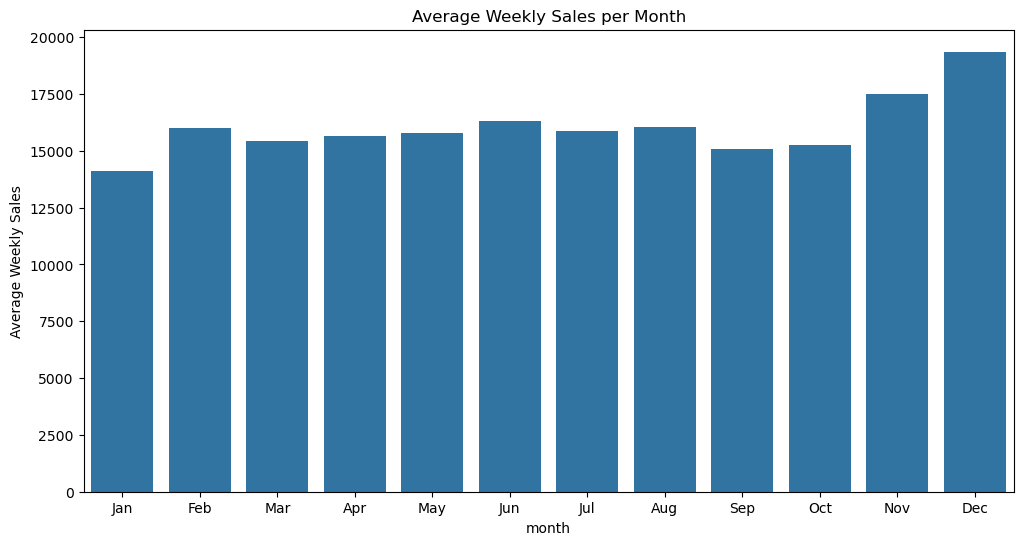

In [118]:
monthly_avg = df.groupby("Month")["Weekly_Sales"].mean()

print(monthly_avg.head(12))

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title("Average Weekly Sales per Month")
plt.xlabel("month")
plt.ylabel("Average Weekly Sales")
plt.xticks(ticks=range(12), labels=month_names)
plt.show()

In [ ]:
Observation:-
    November and December have the highest average weekly sales, showing seasonal peaks.

### Seasonal Trends by Year

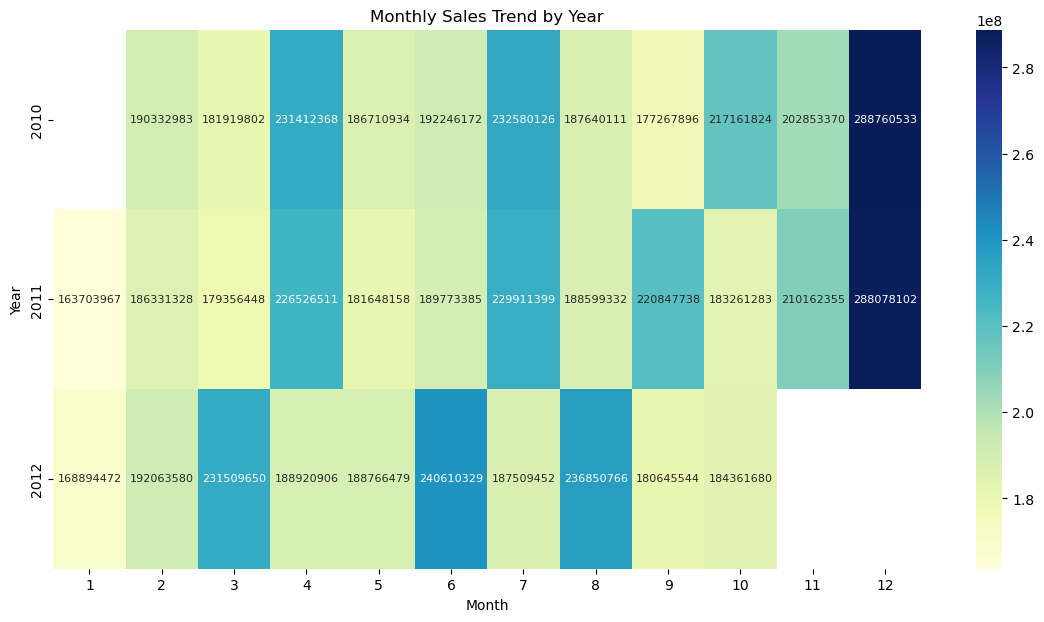

In [119]:
monthly_year_sales = df.groupby(["Year","Month"])["Weekly_Sales"].sum().unstack()

plt.figure(figsize=(14,7))
sns.heatmap(monthly_year_sales, annot=True, fmt=".0f", cmap="YlGnBu", annot_kws={"size":8})
plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

### Heatmaps for Correlation Analysis


In [120]:
cols = df[[  "Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment" ]]

In [121]:
# This shows how strongly variables relate to each other.

corr_matrix = cols.corr()
print(corr_matrix)

              Weekly_Sales  Temperature  Fuel_Price       CPI  Unemployment
Weekly_Sales      1.000000    -0.002312   -0.000120 -0.020921     -0.025864
Temperature      -0.002312     1.000000    0.143859  0.182112      0.096730
Fuel_Price       -0.000120     0.143859    1.000000 -0.164210     -0.033853
CPI              -0.020921     0.182112   -0.164210  1.000000     -0.299953
Unemployment     -0.025864     0.096730   -0.033853 -0.299953      1.000000


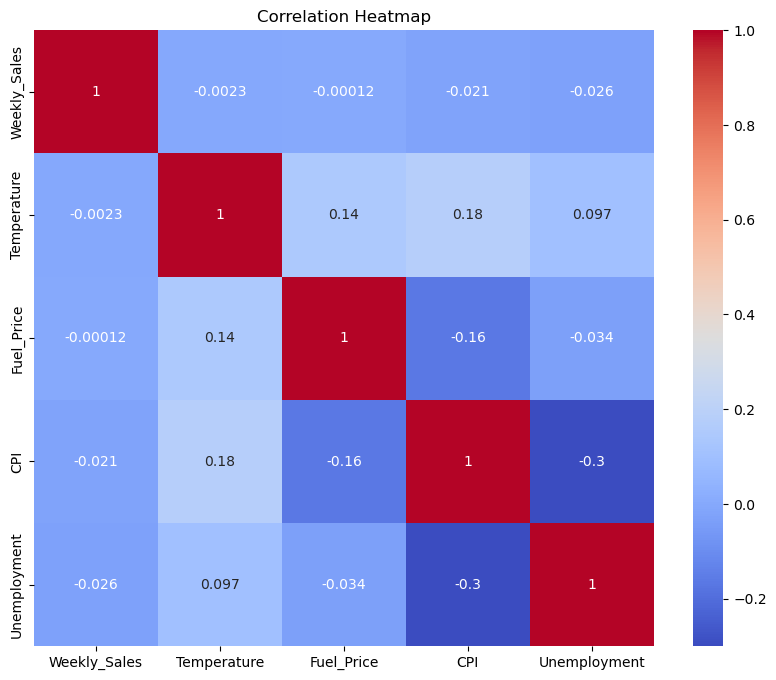

In [55]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Day 3. 

### Stastical Analysis

### T-test

In [122]:
from scipy.stats import ttest_ind

holiday_sales = df[df["IsHoliday"] == True]["Weekly_Sales"]
nonholiday_sales = df[df["IsHoliday"] == False]["Weekly_Sales"]

t_stat, p_value = ttest_ind(holiday_sales, nonholiday_sales)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 8.294756853931894
P-value: 1.0912222677432845e-16


In [ ]:
Observaation:-
    The t-test gave a T-statistic of 8.29 and a very small P-value (1.09e-16). 
Since the P-value is less than 0.05, we reject the null hypothesis. This means 
that weekly sales during holiday weeks are different from non-holiday weeks, 
which shows that holidays affect sales.


### ANOVA

In [123]:
from scipy.stats import f_oneway

dept_groups = [group["Weekly_Sales"].values for name, group in df.groupby("Dept")]

f_stat, p_value = f_oneway(*dept_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)


F-statistic: 6105.784917369253
P-value: 0.0


In [ ]:
Observation:-
    The ANOVA test produced an F-statistic of 6105.78 with a P-value close to 0. 
Since the P-value is less than 0.05, the null hypothesis is rejected. This means 
that weekly sales are significantly different across departments, indicating that 
some departments perform better than others.

### Business Summary

In [ ]:
Most weekly sales are in the lower range, but a few weeks show very high sales.

Sales are higher during holiday weeks. The t-test shows holidays significantly impact sales.

Temperature, fuel price, and CPI have very weak effect on weekly sales.

Sales are different across departments. The ANOVA test confirms departments have different 
average sales.

Sales follow seasonal trends: they increase in March, rise again in summer (June–August),
dip slightly in October–November, and peak in December during the holiday season.

### Day 4. 

### Predictive Modeling (Regression / Forecasting)

### Define Features & Target

In [124]:
X = train.drop(['Weekly_Sales', 'Date'], axis=1)
y = train['Weekly_Sales']

### Train-Test Split

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Model(Linear Regression)

In [126]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Predictions

In [127]:
y_pred = model.predict(X_test)

### Evaluate Model

In [128]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 15130.712403385658
RMSE: 22489.35674937131
R2 Score: 0.03010680573165958


### Try Better Model (Random Forest)

In [129]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2 Score:", r2_score(y_test, y_pred_rf))

RF R2 Score: 0.9005083932083517


### DAY 5. Final Insights + Business Recommendations

### Final Model Comperson

In [133]:
print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Linear Regression R2: 0.03010680573165958
Random Forest R2: 0.9005083932083517


In [ ]:
Observation:
Random Forest performed better than Linear Regression.
Hence, Random Forest is selected as the final model.

### Feature Importance (Key Drivers of Sales)

In [134]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

Dept         0.603480
Store        0.389165
IsHoliday    0.007356
dtype: float64


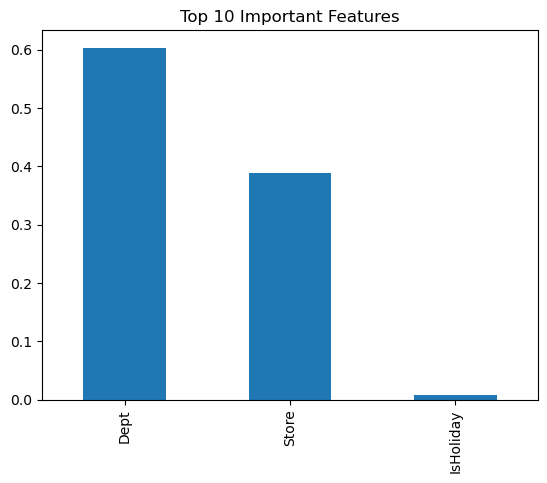

In [70]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

### Key Business Insights

In [ ]:
1. Sales Insights:
a.Weekly sales are highly seasonal
b.Sales peak during holiday periods (especially December)
c.Some departments consistently outperform others

2. External Factors:
a.Temperature, Fuel Price, and CPI have low impact on sales
b.Unemployment shows slight influence but not strong

3. Store & Department:
a.Sales vary significantly across stores and departments
b.Certain stores contribute major revenue

### Business Recommendations

In [ ]:
1.Inventory Planning:
a.Increase stock before holidays and peak seasons

2. Marketing Strategy:
Run promotions during high-sales months (March, Summer, December)

3. Store Optimization:
a.Focus on high-performing stores and departments
b.Improve low-performing ones with offers/placement

4. Demand Forecasting:
a.Use Random Forest model to predict future sales
b.Helps in supply chain planning

### Final Conclusion

In [ ]:
This project analyzed weekly sales data and identified key factors affecting retail performance.
Seasonal trends and holidays significantly influence sales, while external economic factors have minimal impact.
Among models tested, Random Forest provided better predictive accuracy.
The insights can help businesses optimize inventory, marketing, and operational strategies.

### Residual Plot

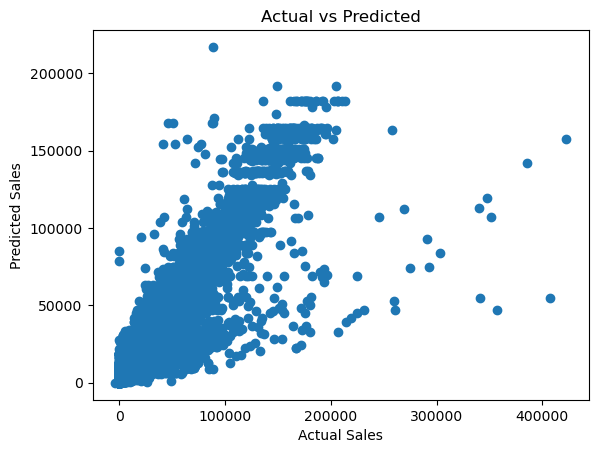

In [132]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

In [135]:
df.to_csv("Cleaned_Data.csv", index=False)